# 04 - Evaluation and Error Analysis

This notebook is the reproducible final evaluation of the corrected OpenFPL pipeline. The fixed split trains on 2020/21-2023/24 and tests only on 2024/25. The primary prospective window is GW32-38; no feature uses the target fixture.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'outputs' / 'results'
FIGURES = ROOT / 'outputs' / 'figures'

summary = json.loads((RESULTS / 'model_summary_fixed.json').read_text(encoding='utf-8'))
metrics = pd.read_csv(RESULTS / 'model_metrics_fixed.csv')
predictions = pd.read_csv(RESULTS / 'predictions_2024_25_fixed.csv')
errors = pd.read_csv(RESULTS / 'largest_errors_fixed.csv')
paper = pd.read_csv(RESULTS / 'paper_comparison_fixed.csv')
cv = pd.read_csv(RESULTS / 'cv_fold_metrics_fixed.csv')
importance = pd.read_csv(RESULTS / 'feature_importance_fixed.csv')

print(f"Best prospective model: {summary['best_model']}")
print(f"Eligible prospective rows: {summary['prospective_rows']:,}")
print(f"Excluded labels: {summary['excluded_test_positions']}")

Best prospective model: XGBoost
Eligible prospective rows: 5,533
Excluded labels: ['AM']


## Overall model comparison

Models are ranked by RMSE on GW32-38. MAE is easier to interpret in FPL points, while RMSE penalizes large misses more strongly.

In [2]:
prospective = (metrics[(metrics['scope'] == 'prospective_gw32_38') & (metrics['group_type'] == 'overall')]
               .sort_values('rmse')
               [['model', 'n', 'mae', 'rmse', 'r2']])
prospective.style.format({'mae': '{:.3f}', 'rmse': '{:.3f}', 'r2': '{:.3f}'})

,model,n,mae,rmse,r2
474,XGBoost,5533,0.944,1.842,0.315
458,Random Forest,5533,0.976,1.846,0.312
442,Linear Regression,5533,0.972,1.856,0.304
410,Last-5 baseline,5533,0.997,2.008,0.186
506,Position RF+XGB ensemble,5533,1.290,2.031,0.167
426,Tier-0 Form+FDR,5533,1.291,2.075,0.130
490,XGBoost weighted,5533,1.354,2.113,0.098
394,Mean baseline,5533,1.447,2.227,-0.002
378,Zero baseline,5533,1.084,2.469,-0.231


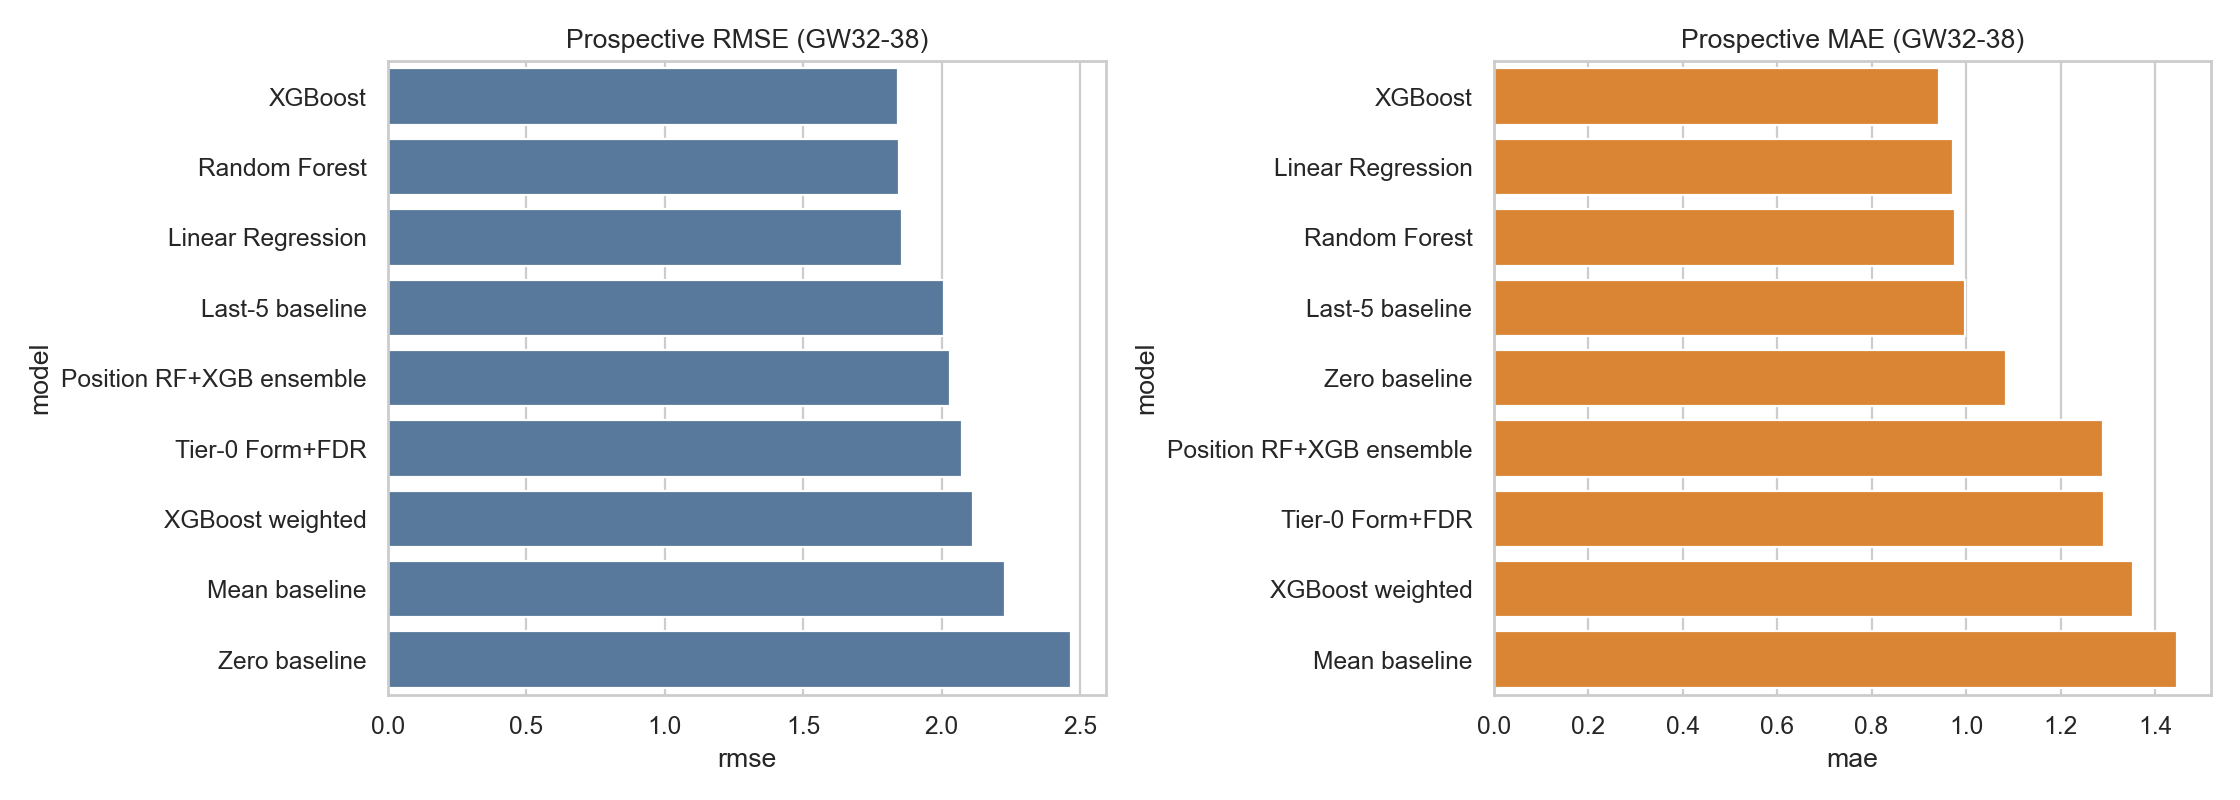

In [3]:
display(Image(filename=str(FIGURES / 'model_comparison_fixed.png')))

**Finding.** Unweighted XGBoost is the best prospective model (RMSE 1.842), but Random Forest and Linear Regression are close. Target reweighting and the compact position ensemble reduce accuracy, so extra complexity is not automatically useful.

## Comparison with the OpenFPL paper

In [4]:
paper.pivot(index='category', columns='method', values='rmse').round(3)

method,Last-5 (paper),OpenFPL,XGBoost
category,,,
Blanks,1.400,1.291,1.396
Haulers,5.613,5.142,5.397
Tickers,2.136,1.517,1.455
Zeros,0.791,0.818,0.759


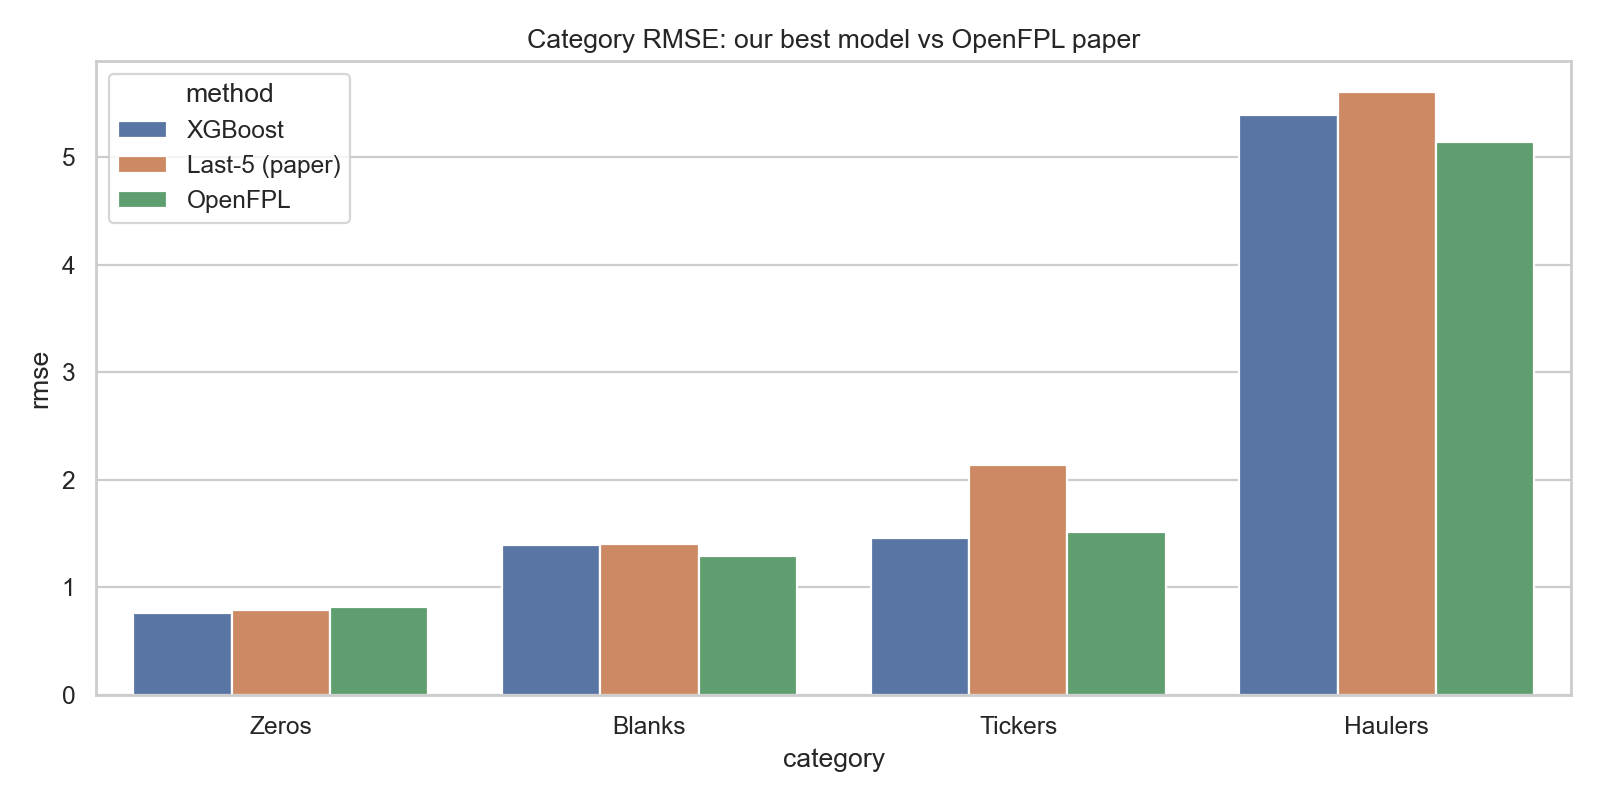

In [5]:
display(Image(filename=str(FIGURES / 'category_rmse_fixed.png')))

This is a partial reproduction, not a claim of exact replication. The public repository does not provide every original Understat-derived feature and the available position labels differ. Our model is better on zeros and tickers, but worse on blanks and haulers. Large returns remain the main weakness.

## Performance by position

In [6]:
pos = (metrics[(metrics['scope'] == 'prospective_gw32_38') &
               (metrics['model'] == summary['best_model']) &
               (metrics['group_type'] == 'position')]
       [['group', 'n', 'mae', 'rmse', 'r2']].rename(columns={'group': 'position'}).sort_values('rmse'))
pos.style.format({'mae': '{:.3f}', 'rmse': '{:.3f}', 'r2': '{:.3f}'})

,position,n,mae,rmse,r2
479,GK,581,0.727,1.651,0.381
481,MID,2452,0.940,1.830,0.342
480,DEF,1884,0.994,1.888,0.256
482,FWD,616,1.005,1.920,0.297


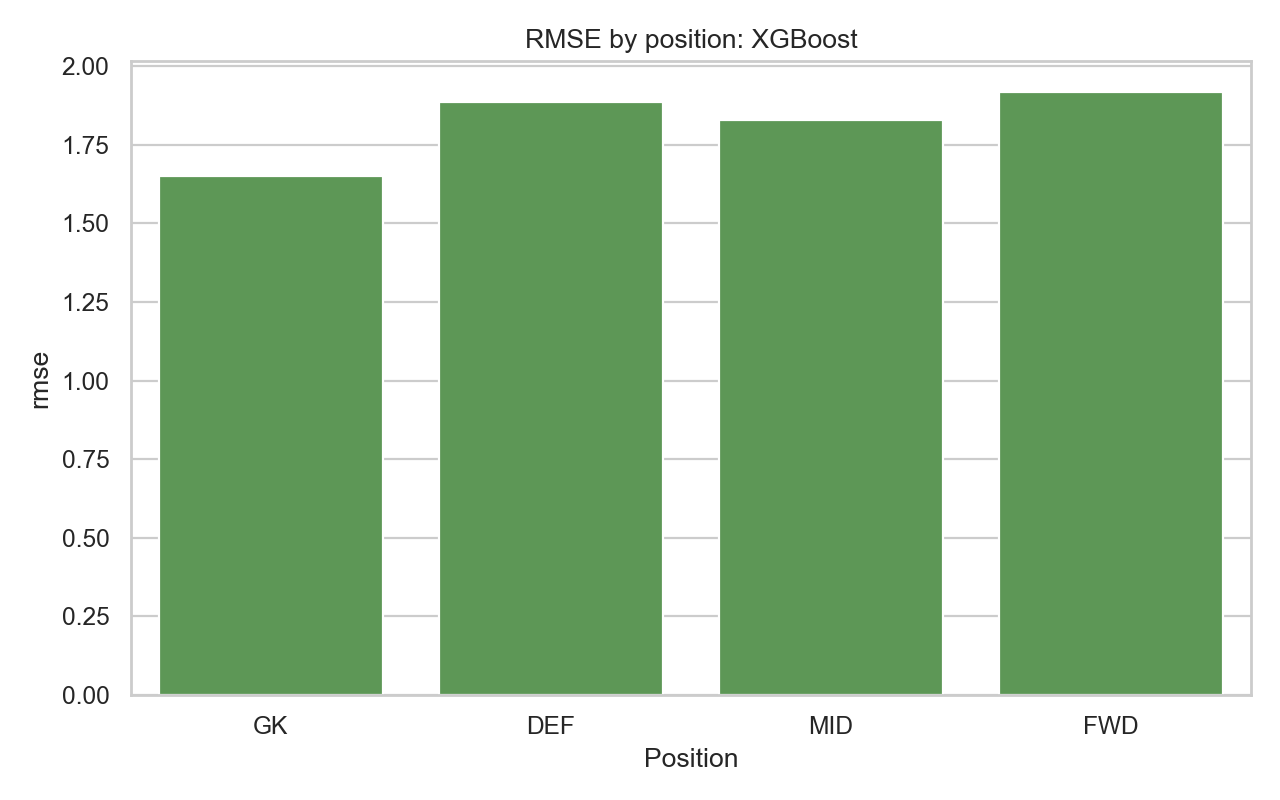

In [7]:
display(Image(filename=str(FIGURES / 'position_rmse_fixed.png')))

## Feature importance

In [8]:
importance.rename(columns={'Unnamed: 0': 'feature'}).head(15).style.format({'importance': '{:.4f}'})

,feature,importance
0,minutes_last_3,0.2704
1,ict_index_last_3,0.1421
2,form_last_3,0.1253
3,selected_pct,0.0447
4,opponent_difficulty,0.0396
5,form_last_5,0.0394
6,opponent_strength,0.0235
7,price,0.0232
8,pos_DEF,0.0192
9,minutes_last_5,0.0186


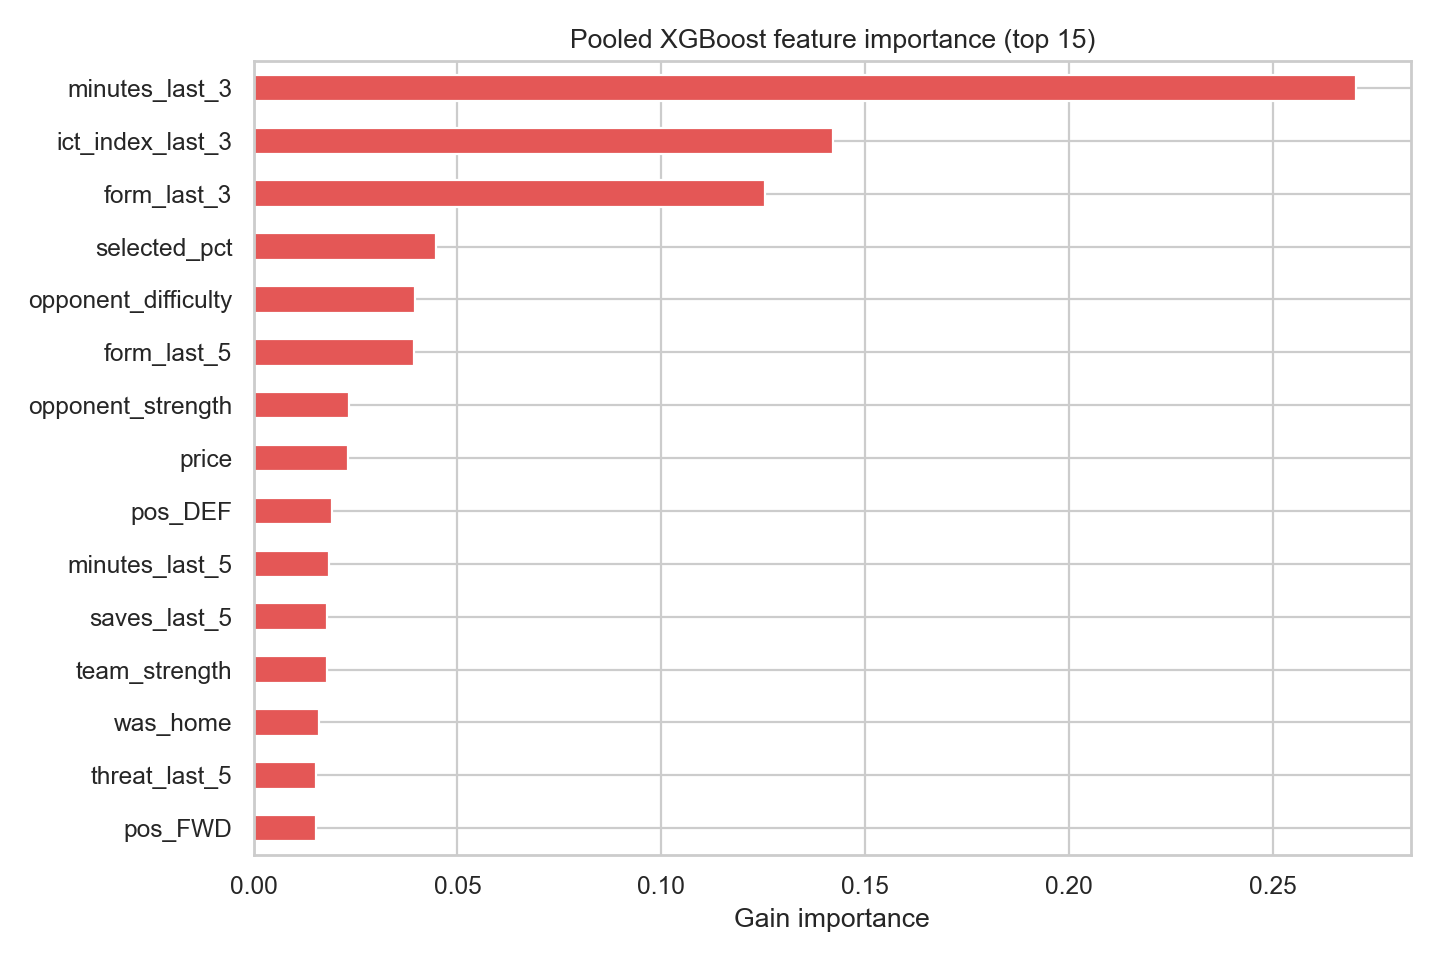

In [9]:
display(Image(filename=str(FIGURES / 'feature_importance_fixed.png')))

Recent minutes, ICT and form dominate the fitted trees. Opponent difficulty and team/opponent strength add context but do not replace the player's own recent involvement.

## Largest errors

In [10]:
cols = ['name', 'position_label', 'round', 'team_name', 'opponent_team', 'actual_points', 'best_prediction', 'error']
errors[cols].head(15).style.format({'actual_points': '{:.1f}', 'best_prediction': '{:.2f}', 'error': '{:+.2f}'})

,name,position_label,round,team_name,opponent_team,actual_points,best_prediction,error
0,Bryan Mbeumo,MID,33,Brentford,5,18.0,4.73,-13.27
1,Levi Colwill,DEF,38,Chelsea,16,15.0,1.80,-13.20
2,Jack Hinshelwood,MID,38,Brighton,18,15.0,2.00,-13.00
3,Aaron Ramsdale,GK,32,Southampton,2,16.0,3.08,-12.92
4,Eberechi Eze,MID,36,Crystal Palace,18,16.0,3.94,-12.06
5,Ezri Konsa Ngoyo,DEF,37,Aston Villa,18,15.0,3.25,-11.75
6,Harvey Elliott,MID,37,Liverpool,5,13.0,1.29,-11.71
7,Leandro Trossard,MID,33,Arsenal,10,16.0,4.49,-11.51
8,Antoine Semenyo,MID,38,Bournemouth,11,16.0,4.66,-11.34
9,Matheus Santos Carneiro Da Cunha,FWD,34,Wolves,11,15.0,3.78,-11.22


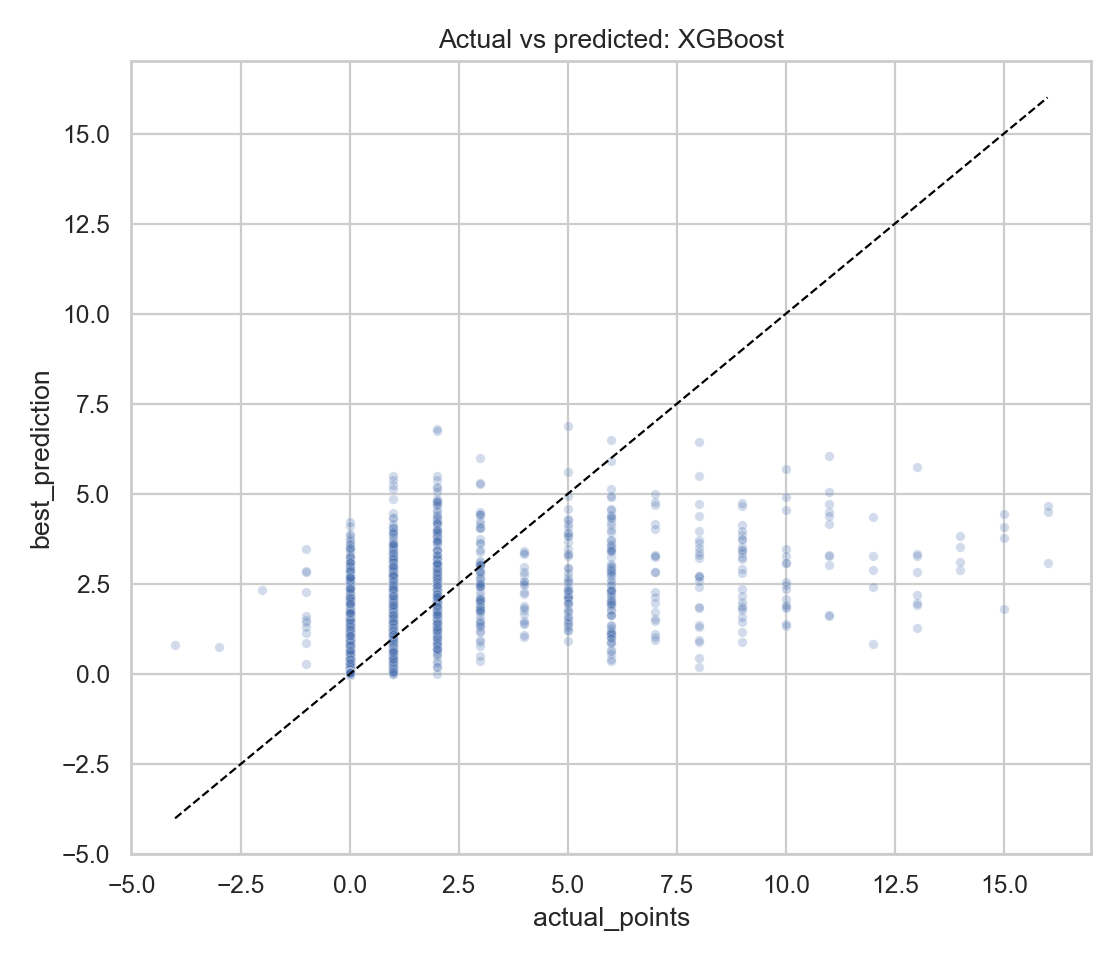

In [11]:
display(Image(filename=str(FIGURES / 'actual_vs_predicted_fixed.png')))

The largest errors are mostly underpredicted hauls. These are rare and depend on events such as goals, assists, penalties and clean sheets, which are difficult to infer from lagged tabular features alone.

## Stable-club cross-validation

In [12]:
cv.style.format({'mae': '{:.3f}', 'rmse': '{:.3f}'})

,fold,n_val,mae,rmse
0,1,22229,1.441,2.196
1,2,20393,1.510,2.283
2,3,19334,1.574,2.421
3,4,16531,1.555,2.317
4,5,15677,1.455,2.192


The grouped folds are harder than the held-out temporal test because whole clubs are kept together. This stress test measures generalization to unseen club contexts; it is supplementary to the season-based test that matches the deployment scenario.

## Conclusion and limitations

- Best model: unweighted XGBoost.
- Strong simple references: Linear Regression and Random Forest.
- Main failure mode: large positive hauls are systematically underestimated.
- The result is leakage-safe and temporally held out, but it is only a partial paper reproduction.
- Useful next work: calibrated uncertainty, richer availability/injury information, betting-market context, and a rolling next-season retraining workflow.